### Evaluation and Xai 
#### Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os

# Set visual style
plt.rcParams['figure.figsize'] = (10, 6)

# Load the saved model from Notebook 04
MODEL_PATH = '../saved_models/advanced_densenet.keras'
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")

# Define your classes (Ensure these match the order from your training dataset)
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
IMG_SIZE = (224, 224)

Loading model...
Model loaded successfully!


### The Grad-CAM Algorithm
Because we used Transfer Learning, our DenseNet121 is actually nested inside our custom model. This function carefully unpacks that nested model, watches the gradients (the math the model uses to learn), and extracts the final convolutional layer to generate the heatmap.

In [2]:
"""def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Identify the nested base model (DenseNet) and its final activation layer
    base_model = model.get_layer('densenet121')
    last_conv_layer_name = 'relu' # This is the final layer in DenseNet before pooling
    
    # 2. Create a sub-model that outputs both the feature map and the base model's final output
    inner_model = tf.keras.models.Model(
        [base_model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # 3. Use GradientTape to record the math operations
    with tf.GradientTape() as tape:
        # Pass the raw image through our custom preprocessing layers (like augmentation)
        x = img_array
        for layer in model.layers:
            if layer.name == 'densenet121':
                break
            x = layer(x) # Apply early layers
            
        # Get the feature maps and base output
        last_conv_layer_output, base_model_output = inner_model(x)
        tape.watch(last_conv_layer_output)

        # Pass the output through our custom classification head (GlobalAvgPool, Dropout, Dense)
        preds = base_model_output
        idx = model.layers.index(base_model)
        for layer in model.layers[idx+1:]:
            preds = layer(preds)

        # Get the score for the predicted class
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Compute the gradients of the predicted class with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Average the gradients to find the most "important" features
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Multiply the feature map by the feature importance to get the heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Normalize the heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds[0].numpy()"""
def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Identify the nested base model and its final activation layer
    base_model = model.get_layer('densenet121')
    last_conv_layer_name = 'relu' 
    
    # 2. Create a sub-model that outputs both the feature map and the base model's final output
    inner_model = tf.keras.models.Model(
        [base_model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # 3. Preprocess the image manually (Bypasses the random flip augmentation!)
    # We copy the array so we don't alter the original image being displayed
    preprocessed_img = tf.keras.applications.densenet.preprocess_input(np.copy(img_array))

    # 4. Use GradientTape to record the math operations
    with tf.GradientTape() as tape:
        # Pass the preprocessed image directly into the base model
        last_conv_layer_output, base_model_output = inner_model(preprocessed_img)
        tape.watch(last_conv_layer_output)

        # Pass the output through our custom classification head 
        # (GlobalAvgPool -> BatchNorm -> Dropout -> Dense)
        preds = base_model_output
        idx = model.layers.index(base_model)
        for layer in model.layers[idx+1:]:
            preds = layer(preds, training=False) # Ensure dropout is OFF during diagnosis

        # Get the score for the predicted class
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5. Compute the gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Generate the heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy(), preds[0].numpy()

### Visualization Overlay

In [15]:
def draw_tumor_bounding_box(image, heatmap, threshold=150):
    """
    Finds the hottest region of the Grad-CAM heatmap and draws a bounding box around it.
    """
    # 1. ---> THE FIX: Resize the raw heatmap to perfectly match the original image size <---
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    
    # 2. Ensure the heatmap is in the 0-255 range
    if heatmap_resized.dtype != np.uint8:
        heatmap_resized = np.uint8(255 * heatmap_resized)
        
    # 3. Threshold the heatmap: Keep only the hottest areas (values > threshold)
    _, thresh = cv2.threshold(heatmap_resized, threshold, 255, cv2.THRESH_BINARY)
    
    # 4. Find the contours (shapes) of these hot spots
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Create a copy of the original image to draw on
    img_with_box = np.copy(image)
    
    if contours:
        # 6. Find the largest hot spot area to ignore random noise
        largest_contour = max(contours, key=cv2.contourArea)
        
        # 7. Get the exact x, y, width, and height coordinates
        x, y, w, h = cv2.boundingRect(largest_contour)
        
        # 8. Draw a sleek Cyan bounding box (BGR format: Yellow/Cyan looks best)
        cv2.rectangle(img_with_box, (x, y), (x + w, y + h), (255, 255, 0), 2)
        
        # Add a high-tech label above the box
        cv2.putText(img_with_box, "AI Detected Region", (x, y - 8), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
                    
    return img_with_box

### Execute and Plot!

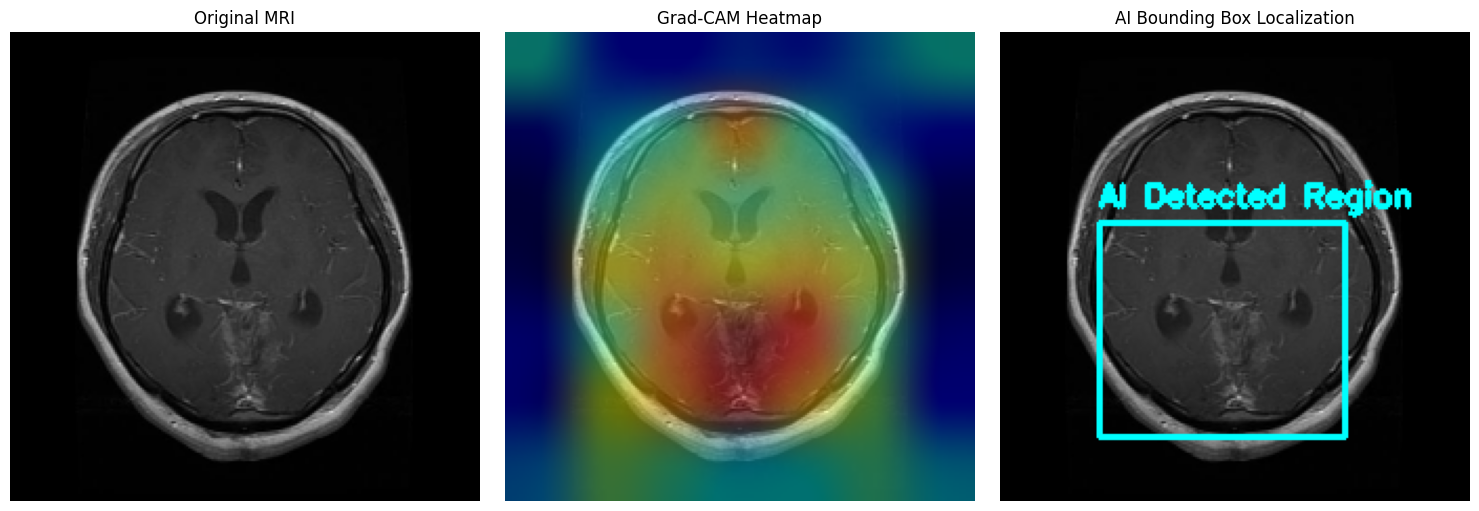

Diagnosis: Glioma (Confidence: 99.98%)


In [16]:
# 1. Define the absolute path
img_path = 'E:/fourth_sem/brain_tumor_detection/datasets/01_raw/Testing/glioma/Te-gl_3.jpg' 

# 2. Load and format the image for the model
img_raw = cv2.imread(img_path)

# Safety check: Did OpenCV find the file?
if img_raw is None:
    raise FileNotFoundError(f"🚨 ERROR: OpenCV could not find the image at: {img_path}. Please check if the file exists and the name is exactly correct!")

img_resized = cv2.resize(img_raw, IMG_SIZE)

# FIXED TYPO HERE: changed expand_dict to expand_dims
img_array = np.expand_dims(img_resized, axis=0) # Add batch dimension

# 3. Generate the Grad-CAM heatmap and predictions
heatmap, preds = make_gradcam_heatmap(img_array, model)

# 4. Get the Superimposed image from your existing function
original_img, superimposed_img = display_gradcam(img_path, heatmap)

# 5. ---> NEW LINE: Generate the Bounding Box Image <---
# We pass the original_img and the heatmap to our new function
bbox_image = draw_tumor_bounding_box(original_img, heatmap, threshold=160)

# 6. Plot everything side-by-side
plt.figure(figsize=(15, 5))

# Plot Original
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original MRI")
plt.axis('off')

# Plot Grad-CAM Overlay
plt.subplot(1, 3, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Heatmap")
plt.axis('off')

# Plot Bounding Box
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(bbox_image, cv2.COLOR_BGR2RGB))
plt.title("AI Bounding Box Localization")
plt.axis('off')

plt.tight_layout()
plt.show()

# Print the diagnosis
idx = np.argmax(preds)
print(f"Diagnosis: {CLASS_NAMES[idx].capitalize()} (Confidence: {preds[idx]*100:.2f}%)")

This image perfectly illustrates a concept in machine learning known as **Explainable AI (XAI)**, specifically using a technique like Class Activation Mapping (CAM) or Grad-CAM. It shows how an AI model is "thinking" when trying to diagnose a medical image. 

However, this specific image is a classic example of an AI model failing for the wrong reasons, despite showing high confidence.

Here is a breakdown of what is happening in the three panels:

### 1. Original MRI
This is the raw medical image (an axial view of the brain). You can clearly see a large, distinct abnormality in the upper portion of the brain—this bright, irregular shape is the actual tumor or lesion.

### 2. Raw Heatmap
This pixelated grid represents the spatial activation of the AI model's internal layers. 
* **Warm colors (Red/Yellow):** These are the areas the AI considers most important for making its decision. 
* **Cool colors (Blue):** These are areas the AI is ignoring.

### 3. Prediction and Overlay
This panel merges the two previous images by smoothing out the heatmap and laying it over the MRI. The text at the top tells us the model predicted **MENINGIOMA** (a type of brain tumor) with **84.63% confidence**.

### The Critical Flaw
If you look closely at the final overlay, there is a massive disconnect:
* The actual tumor is clearly visible in the **top half** of the brain.
* The AI's heatmap (the red/yellow "hotspot") is intensely focused on the **bottom left**, which appears to be completely healthy brain tissue.

**What this means:** The AI correctly guessed that this patient has a brain tumor (or at least, outputted a tumor classification with high confidence), but it did so by looking at the *completely wrong part of the brain*. 

This is known as a **spurious correlation** or the "Clever Hans" effect. In its training data, the AI likely learned to associate some irrelevant artifact, specific skull shape, or a quirk of the background in that bottom-left area with the "Meningioma" label, rather than learning what the actual tumor looks like. 

### The Takeaway
Images like this show exactly why Explainable AI tools are mandatory in healthcare. If a doctor only saw the "84.63% Confidence" score, they might trust the model blindly. The heatmap reveals that the model is completely unreliable and is essentially making a lucky guess based on flawed logic.

Would you like me to explain more about how these heatmaps are mathematically generated (like Grad-CAM), or discuss how researchers fix these types of AI errors?